# BLM National AIM — Landscape Monitoring Framework (LMF) public geodatabase

Loads `datasets/raw/BLM_Natl_AIM_LMF_Public.gdb` and summarizes what is in it.

**What it is.** The BLM Assessment, Inventory, and Monitoring (AIM) program's terrestrial field data for the
**Landscape Monitoring Framework (LMF)**: a long-running, statistically designed network of ground plots on
western US rangelands (mostly BLM-administered land). Each row in the main tables is one **plot visit**
(`PrimaryKey` / `PlotKey`, e.g. `2023563100103B1` = survey year + state/county FIPS + PSU + point).
Field crews measure vegetation cover and height, soil, gaps in plant canopy, species composition and rangeland-health
attributes using standard line-point-intercept protocols.

**Layout of the geodatabase** (read with `pyogrio`/`geopandas`; layers are tables, only three have point geometry):

| Group | Layers | Contents |
|---|---|---|
| Derived indicators (`I_`) | `I_Indicators`, `I_Species` | One row per plot (cover %, height, gap, soil stability, species counts); one row per plot × species (cover, height, traits) |
| Plot metadata (`F_`) | `F_POINT`, `F_POINTCOORDINATES`, `F_GPS`, `F_POINTWEIGHT` | Site/soil/slope/ownership, target vs. field coordinates, plot shape/size, sampling weights |
| Raw field data (`F_`) | `F_PINTERCEPT`, `F_GINTERCEPT`, `F_PASTUREHEIGHTS`, `F_PLANTCENSUS`, `F_SOILHORIZON`, `F_SOILDISAG`, `F_ESFSG` | Line-point intercept hits, canopy/basal gap intervals, plant heights, plant counts, soil horizons, soil disaggregation, ecological-site/forage-group coverage |
| Qualitative assessments (`F_`) | `F_RANGEHEALTH`, `F_RHSUMMARY`, `F_CONCERN`, `F_DISTURBANCE` | Rangeland-health indicators, resource concerns, land-use disturbance |
| Lookups (`AIM_Terrestrial__F_`) | `tblNationalPlants`, `tblStateSpecies`, `tblStateNoxiousSpecies` | Plant taxonomy and traits (growth habit, duration, native/invasive/noxious) |

Large (≈1.7 GB); the heavy raw-data layers are only counted here, not loaded.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import pyogrio
import matplotlib.pyplot as plt

def find_repo_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / 'datasets' / 'raw').exists():
            return p
    raise FileNotFoundError('run from inside the repository')

GDB = find_repo_root() / 'datasets' / 'raw' / 'BLM_Natl_AIM_LMF_Public.gdb'
PREFIX = 'AIM_TerrestrialLMF__'
pd.set_option('display.max_columns', 60, 'display.width', 160)
print(GDB)

/Users/sala6791/Library/CloudStorage/OneDrive-UCB-O365/Documents/EAGLE/datasets/raw/BLM_Natl_AIM_LMF_Public.gdb


## 1. Layers

In [2]:
rows = []
for name, geom in pyogrio.list_layers(GDB):
    info = pyogrio.read_info(GDB, layer=name)
    rows.append(dict(layer=name.replace('AIM_Terrestrial', ''), geometry=geom, rows=info['features'], columns=len(info['fields'])))
layers = pd.DataFrame(rows)
layers

,layer,geometry,rows,columns
0,LMF__I_Indicators,Point,21749,135
1,LMF__F_POINTWEIGHT,NaN,21749,11
2,LMF__F_POINT,NaN,21749,52
3,LMF__F_GPS,NaN,21749,14
4,LMF__F_GINTERCEPT,NaN,1315841,15
5,LMF__F_CONCERN,NaN,21749,32
6,LMF__F_SOILHORIZON,NaN,47968,16
7,LMF__F_DISTURBANCE,NaN,86996,46
8,LMF__F_RHSUMMARY,NaN,19369,25
9,LMF__F_RANGEHEALTH,NaN,21749,30


## 2. Plot-level indicators (`I_Indicators`)

One row per plot visit with point geometry (NAD83, EPSG:4269). This is the best table to start from.

In [3]:
ind = gpd.read_file(GDB, layer=PREFIX + 'I_Indicators', engine='pyogrio')
ind['Year'] = ind['DateVisited'].dt.year
print(ind.shape, ind.crs)
print('unique plots:', ind.PlotKey.nunique(), '| years:', ind.Year.min(), '-', ind.Year.max())
ind[['PlotKey', 'State', 'CountyName', 'DateVisited', 'EcolSiteName', 'TotalFoliarCover', 'BareSoilCover',
     'AH_SagebrushCover', 'AH_InvasiveCover', 'NumSpp_Total']].head()

(21749, 137) EPSG:4269
unique plots: 21749 | years: 2011 - 2024


,PlotKey,State,CountyName,DateVisited,EcolSiteName,TotalFoliarCover,BareSoilCover,AH_SagebrushCover,AH_InvasiveCover,NumSpp_Total
0,2023563100103B1,WY,Big Horn,2023-07-07 12:00:00+00:00,Saline Upland Clayey (SUC) Big Horn Basin Rim,72.28,13.86,0.00,65.35,12.0
1,2023881100116B1,CO,Moffat,2023-10-19 12:00:00+00:00,Rolling Loam,57.43,13.86,19.80,17.82,16.0
2,20233213100120B1,NV,Humboldt,2023-09-25 12:00:00+00:00,LOAMY 8-10 P.Z.,49.50,27.72,30.69,12.87,11.0
3,20231673100204B1,ID,Owyhee,2023-07-18 12:00:00+00:00,Loamy 8-12 PZ,55.45,20.79,32.67,0.00,6.0
4,2023881100208B1,CO,Moffat,2023-10-24 12:00:00+00:00,No Eco Site established (XE) from the State co...,95.05,1.98,46.53,4.95,28.0


In [4]:
# column groups by prefix
groups = pd.Series(ind.columns).str.extract(r'^([A-Za-z]+)_')[0].fillna('(meta)').value_counts()
print(groups.to_string())

0
AH                51
(meta)            30
FH                23
Hgt               13
NumSpp             6
GapCover           4
SoilStability      3
SagebrushShape     3
COUNTY             1
STATE              1
Latitude           1
Longitude          1


In [5]:
ind.columns.to_list()


['PrimaryKey',
 'V1PrimaryKey',
 'PlotKey',
 'PlotID',
 'AdminState',
 'State',
 'CountyName',
 'COUNTY_FIPS',
 'STATE_FIPS',
 'FIPS',
 'DesignName',
 'DesignPointKey',
 'Stratum',
 'DesignPolygonID',
 'SegmentPolygonID',
 'Purpose',
 'PurposeFlag',
 'DesignFlag',
 'SamplingApproach',
 'EcologicalSiteId',
 'EcolSiteName',
 'EcolSiteSource',
 'Latitude_NAD83',
 'Longitude_NAD83',
 'DateEstablished',
 'DateVisited',
 'GapCover_25_50',
 'GapCover_51_100',
 'GapCover_101_200',
 'GapCover_200_plus',
 'SoilStability_All',
 'SoilStability_Protected',
 'SoilStability_Unprotected',
 'TotalFoliarCover',
 'BareSoilCover',
 'AH_ForbCover',
 'AH_PerenForbCover',
 'AH_AnnForbCover',
 'AH_PreferredForbCover',
 'AH_GrassCover',
 'AH_GraminoidCover',
 'AH_PerenGrassCover',
 'AH_PerenGraminoidCover',
 'AH_C3PerenGrassCover',
 'AH_C4PerenGrassCover',
 'AH_AnnGrassCover',
 'AH_AnnGraminoidCover',
 'AH_TallPerenGrassCover',
 'AH_ShortPerenGrassCover',
 'AH_PerenForbGraminoidCover',
 'AH_ShrubCover',
 'AH_S

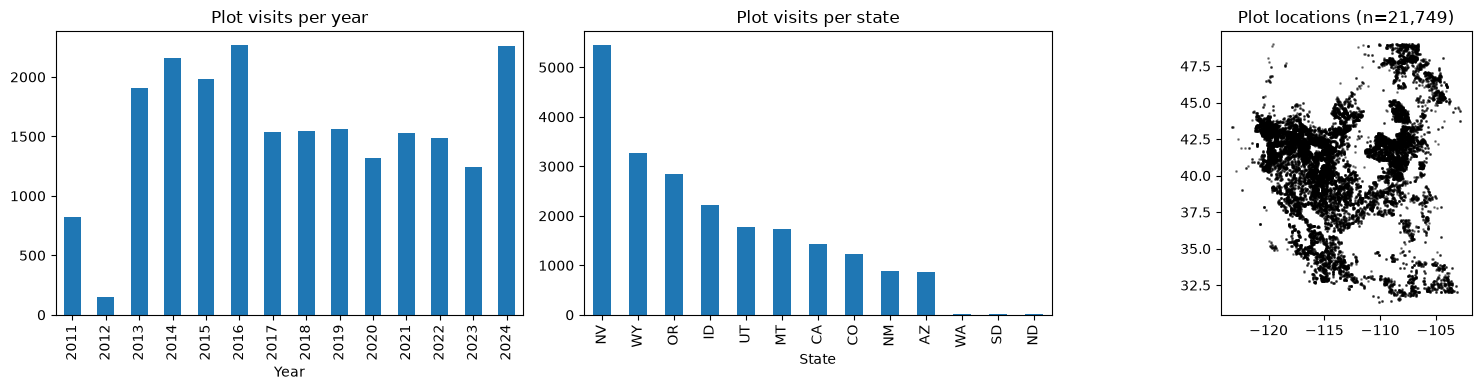

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ind.Year.value_counts().sort_index().plot.bar(ax=axes[0], title='Plot visits per year')
ind.State.value_counts().plot.bar(ax=axes[1], title='Plot visits per state')
ind.plot(ax=axes[2], markersize=1, color='k', alpha=.4)
axes[2].set_title(f'Plot locations (n={len(ind):,})')
plt.tight_layout()

In [7]:
# convert crs
# I_Indicators geometry is already NAD83 (EPSG:4269); reproject to WGS84 (EPSG:4326)
ind = ind.to_crs(4326)

# Replace the NAD83 lat/lon columns with WGS84 values from the new geometry
ind['Latitude_WGS84'] = ind.geometry.y
ind['Longitude_WGS84'] = ind.geometry.x

In [43]:
ind.columns.to_list()

['PrimaryKey',
 'V1PrimaryKey',
 'PlotKey',
 'PlotID',
 'AdminState',
 'State',
 'CountyName',
 'COUNTY_FIPS',
 'STATE_FIPS',
 'FIPS',
 'DesignName',
 'DesignPointKey',
 'Stratum',
 'DesignPolygonID',
 'SegmentPolygonID',
 'Purpose',
 'PurposeFlag',
 'DesignFlag',
 'SamplingApproach',
 'EcologicalSiteId',
 'EcolSiteName',
 'EcolSiteSource',
 'Latitude_NAD83',
 'Longitude_NAD83',
 'DateEstablished',
 'DateVisited',
 'GapCover_25_50',
 'GapCover_51_100',
 'GapCover_101_200',
 'GapCover_200_plus',
 'SoilStability_All',
 'SoilStability_Protected',
 'SoilStability_Unprotected',
 'TotalFoliarCover',
 'BareSoilCover',
 'AH_ForbCover',
 'AH_PerenForbCover',
 'AH_AnnForbCover',
 'AH_PreferredForbCover',
 'AH_GrassCover',
 'AH_GraminoidCover',
 'AH_PerenGrassCover',
 'AH_PerenGraminoidCover',
 'AH_C3PerenGrassCover',
 'AH_C4PerenGrassCover',
 'AH_AnnGrassCover',
 'AH_AnnGraminoidCover',
 'AH_TallPerenGrassCover',
 'AH_ShortPerenGrassCover',
 'AH_PerenForbGraminoidCover',
 'AH_ShrubCover',
 'AH_S

In [8]:
ind['FH_ForbCover']

0         2.97
1        27.72
2        10.89
3         3.96
4         5.94
         ...  
21744     0.00
21745    18.81
21746     9.90
21747     0.00
21748     0.99
Name: FH_ForbCover, Length: 21749, dtype: float64

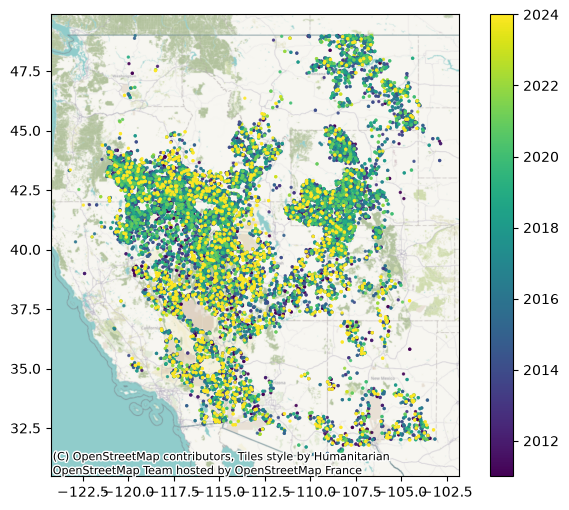

In [9]:
# plot map with base layer
import contextily as ctx
fig, ax = plt.subplots(figsize=(8, 6))
ind.plot(column='Year',legend=True, markersize=2, alpha=.8, figsize=(8, 6), ax=ax)#, cmap='')
ctx.add_basemap(ax, crs=ind.crs.to_string())

,count,mean,std,min,25%,50%,75%,max
TotalFoliarCover,21749.0,47.5,22.5,0.0,30.7,45.5,63.4,100.0
BareSoilCover,21749.0,26.3,20.1,0.0,9.9,22.8,38.6,100.0
AH_ShrubCover,21749.0,15.7,12.9,0.0,5.0,13.9,23.8,99.0
AH_SagebrushCover,21749.0,10.0,11.5,0.0,0.0,5.1,17.8,81.2
AH_GrassCover,21749.0,27.9,23.9,0.0,6.9,22.8,42.6,100.0
AH_ForbCover,21749.0,7.8,11.4,0.0,1.0,4.0,9.9,96.0
AH_TotalLitterCover,21749.0,35.8,22.7,0.0,17.8,32.7,50.5,100.0
AH_InvasiveCover,21749.0,10.5,18.1,0.0,0.0,1.0,12.9,100.0
AH_NonNativeCover,21749.0,12.1,19.2,0.0,0.0,2.0,15.8,100.0
FH_TreeCover,21749.0,1.9,6.9,0.0,0.0,0.0,0.0,75.2


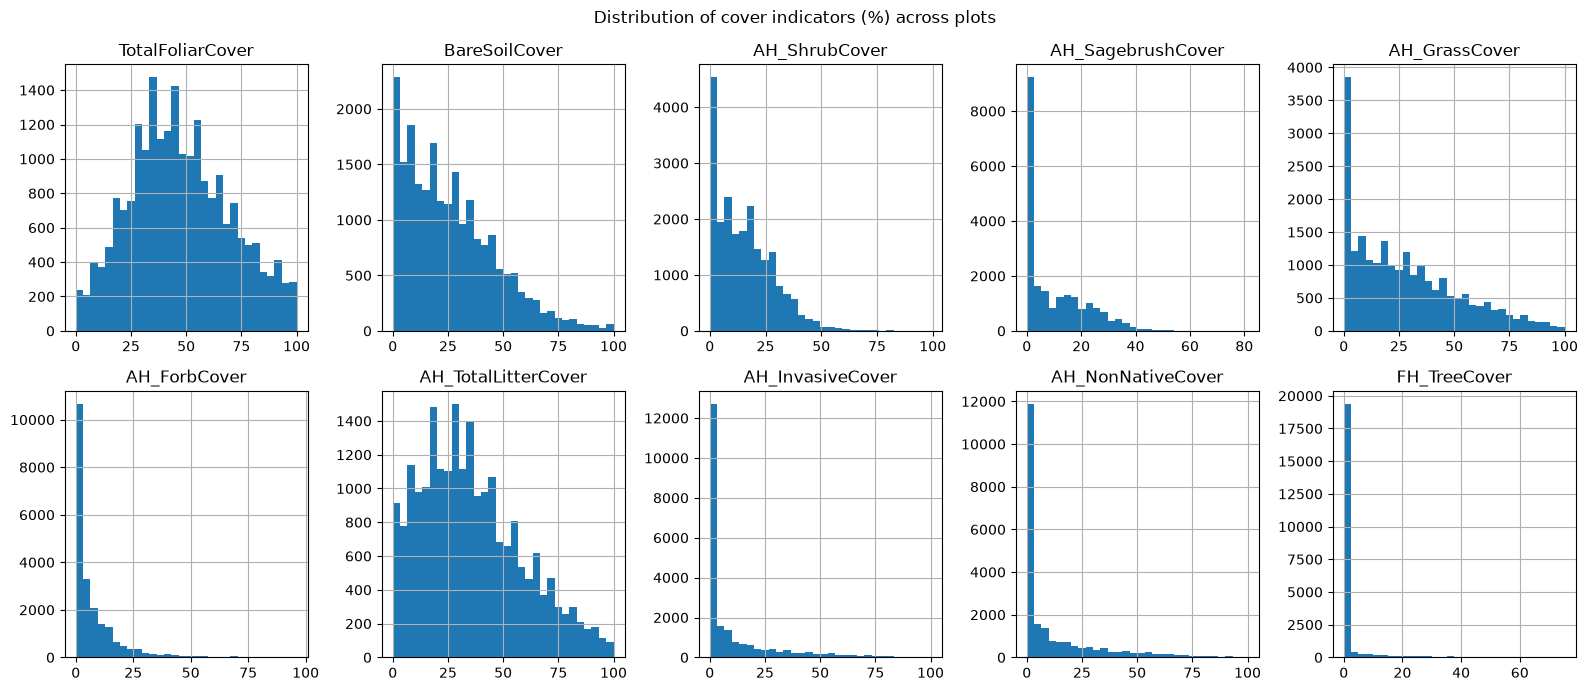

In [10]:
cover_cols = ['TotalFoliarCover', 'BareSoilCover', 'AH_ShrubCover', 'AH_SagebrushCover', 'AH_GrassCover',
              'AH_ForbCover', 'AH_TotalLitterCover', 'AH_InvasiveCover', 'AH_NonNativeCover', 'FH_TreeCover']
display(ind[cover_cols].describe().T.round(1))
ind[cover_cols].hist(bins=30, figsize=(16, 7), layout=(2, 5))
plt.suptitle('Distribution of cover indicators (%) across plots')
plt.tight_layout()

,count,mean,std,min,25%,50%,75%,max
Hgt_Woody_Avg,20007.0,55.8,71.3,2.5,25.0,37.7,56.7,1862.8
Hgt_Herbaceous_Avg,21255.0,23.8,13.0,1.3,14.6,21.8,30.9,624.8
Hgt_Forb_Avg,15072.0,19.9,16.2,1.3,8.7,15.2,27.3,779.1
Hgt_PerenForb_Avg,9228.0,18.5,14.0,1.3,7.6,15.2,25.4,111.8
Hgt_Graminoid_Avg,20127.0,24.9,12.2,1.3,16.0,23.2,32.0,127.0
Hgt_PerenGraminoid_Avg,18294.0,27.5,12.9,1.3,17.8,25.8,35.0,127.0
Hgt_TallPerenGrass_Avg,15994.0,30.4,14.4,1.9,19.9,28.2,39.0,130.2
Hgt_ShortPerenGrass_Avg,10082.0,23.2,11.8,1.3,13.8,22.9,31.3,84.0
Hgt_PerenForbGraminoid_Avg,19347.0,26.2,13.0,1.3,16.7,24.6,33.8,127.0
Hgt_Shrub_Avg,19036.0,42.9,28.8,2.5,26.4,37.2,51.8,937.3


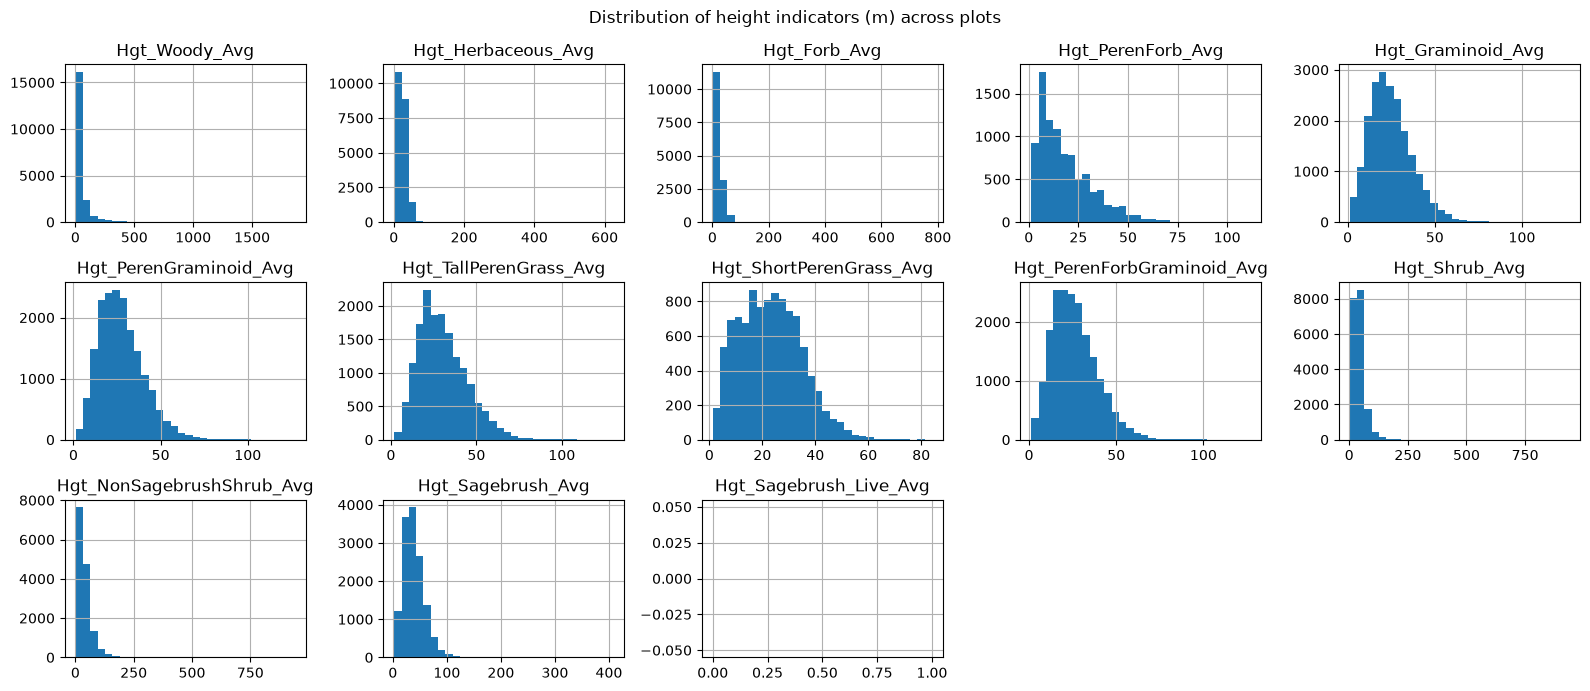

In [11]:
hgt_cols = ['Hgt_Woody_Avg',
 'Hgt_Herbaceous_Avg',
 'Hgt_Forb_Avg',
 'Hgt_PerenForb_Avg',
 'Hgt_Graminoid_Avg',
 'Hgt_PerenGraminoid_Avg',
 'Hgt_TallPerenGrass_Avg',
 'Hgt_ShortPerenGrass_Avg',
 'Hgt_PerenForbGraminoid_Avg',
 'Hgt_Shrub_Avg',
 'Hgt_NonSagebrushShrub_Avg',
 'Hgt_Sagebrush_Avg',
 'Hgt_Sagebrush_Live_Avg']
display(ind[hgt_cols].describe().T.round(1))
ind[hgt_cols].hist(bins=30, figsize=(16, 7), layout=(3,5))
plt.suptitle('Distribution of height indicators (m) across plots')
plt.tight_layout()

In [12]:
# fraction missing per column (top 15) - indicators that are not measured on every plot
ind.drop(columns='geometry').isna().mean().sort_values(ascending=False).head(15).round(3)

DateEstablished                   1.000
Hgt_Sagebrush_Live_Avg            1.000
DesignPolygonID                   1.000
Hgt_PerenForb_Avg                 0.576
Hgt_ShortPerenGrass_Avg           0.536
SagebrushShape_All_Predominant    0.397
Hgt_Sagebrush_Avg                 0.369
Hgt_NonSagebrushShrub_Avg         0.335
Hgt_Forb_Avg                      0.307
Hgt_TallPerenGrass_Avg            0.265
Hgt_PerenGraminoid_Avg            0.159
SoilStability_Protected           0.128
Hgt_Shrub_Avg                     0.125
Hgt_PerenForbGraminoid_Avg        0.110
Hgt_Woody_Avg                     0.080
dtype: float64

In [13]:
# what vegetation communities are covered? top ecological sites and design/sampling info
display(ind.EcolSiteName.value_counts().head(10))
display(ind[['DesignName', 'Stratum', 'SamplingApproach', 'PurposeFlag']].apply(lambda s: s.value_counts(dropna=False).to_dict()))

EcolSiteName
No Eco Site established (XE) from the State coverage menu    1588
LOAMY 8-10 P.Z.                                              1015
SHALLOW CALCAREOUS LOAM 8-10 P.Z.                             474
LOAMY  10-12 PZ                                               442
Loamy 8-12 PZ                                                 433
LOAMY 5-8 P.Z.                                                244
LOAMY 10-12 P.Z.                                              220
LOAMY 10-13                                                   208
Sandy Green River and Great Divide Basins (Sy)                194
Loamy Green River and Great Divide Basins (Ly)                189
Name: count, dtype: int64

DesignName          {'LMF_2014': 16616, 'LMF_2011': 2876, 'LMF_202...
Stratum                            {'Type I': 13651, 'Type II': 8098}
SamplingApproach                          {'Two Stage Random': 21749}
PurposeFlag                             {'National Reporting': 21749}
dtype: object

## 3. Species composition (`I_Species`)

In [14]:
sp = gpd.read_file(GDB, layer=PREFIX + 'I_Species', engine='pyogrio', read_geometry=False)
print(sp.shape, '| plots:', sp.PrimaryKey.nunique(), '| unique species codes:', sp.Species.nunique())
display(sp[['PrimaryKey', 'Species', 'ScientificName', 'AH_SpeciesCover', 'Hgt_Species_Avg', 'GrowthHabitSub',
            'Duration', 'Nonnative', 'Invasive']].sample(20))
top = (sp.groupby(['Species', 'ScientificName']).agg(plots=('PrimaryKey', 'nunique'), mean_cover=('AH_SpeciesCover', 'mean'))
         .sort_values('plots', ascending=False).head(15).round(2))
top

(364937, 29) | plots: 21749 | unique species codes: 4241


,PrimaryKey,Species,ScientificName,AH_SpeciesCover,Hgt_Species_Avg,GrowthHabitSub,Duration,Nonnative,Invasive
191451,20165617105703B2,ATGA,Atriplex gardneri,6.93,11.85,SubShrub,Perennial,NATIVE,NaN
227862,20175637103414B2,HECO26,Hesperostipa comata,10.89,20.55,Graminoid,Perennial,NATIVE,NaN
157211,20153227203620B2,KRLA2,Krascheninnikovia lanata,0.00,0.00,SubShrub,Perennial,NATIVE,NaN
188952,20163213101613B3,CHVI8,Chrysothamnus viscidiflorus,0.00,0.00,Shrub,Perennial,NATIVE,NaN
147788,20153027105312B1,2FA1,NaN,1.98,0.00,Forb,NaN,NaN,NaN
304096,20215635103505B2,ATCO,Atriplex confertifolia,0.00,15.24,Shrub,Perennial,NATIVE,NaN
79620,20125635050201R3,ORTHO,Orthocarpus,0.00,0.00,Forb,Annual,NATIVE,NaN
8960,20233069104120B2,MEOF,Melilotus officinalis,0.00,0.00,Forb,Annual,EXOTIC,Invasive
305491,2021881100713B2,ARTRW8,Artemisia tridentata subsp. wyomingensis,17.82,52.95,Shrub,Perennial,NATIVE,NaN
263918,2018881102219B1,HECO26,Hesperostipa comata,0.00,0.00,Graminoid,Perennial,NATIVE,NaN


,,plots,mean_cover
Species,ScientificName,,
POSE,Poa secunda,13224,9.79
BRTE,Bromus tectorum,10875,14.19
ELEL5,Elymus elymoides,10623,1.93
ARTRW8,Artemisia tridentata subsp. wyomingensis,9484,12.15
CHVI8,Chrysothamnus viscidiflorus,9209,3.06
ACHY,Achnatherum hymenoides,7714,1.68
PSSP6,Pseudoroegneria spicata,6619,6.62
PHHO,Phlox hoodii,5486,1.33
OPPO,Opuntia polyacantha,5485,0.48


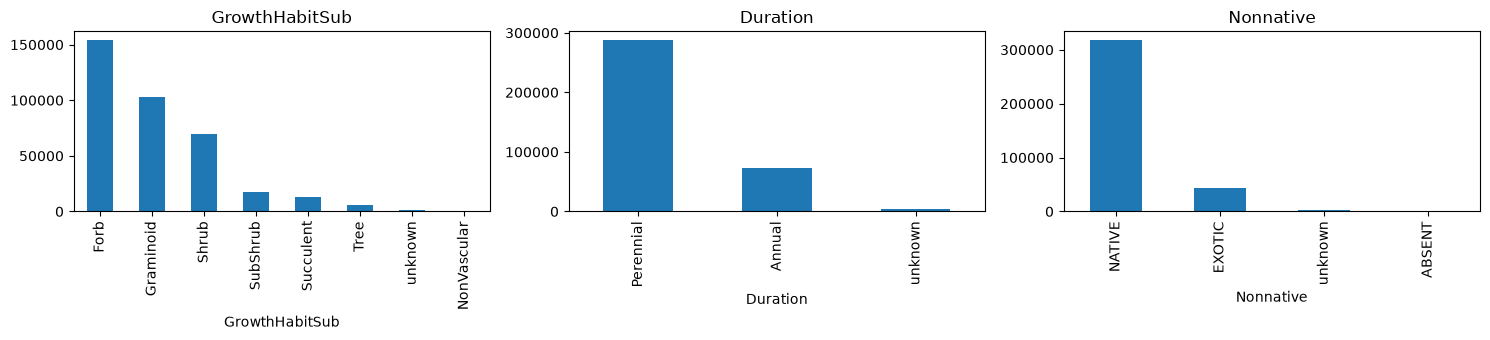

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, ['GrowthHabitSub', 'Duration', 'Nonnative']):
    sp[col].fillna('unknown').value_counts().plot.bar(ax=ax, title=col)
plt.tight_layout()

## 4. Plot metadata (`F_POINT`, `F_POINTCOORDINATES`)

In [16]:
pt = gpd.read_file(GDB, layer=PREFIX + 'F_POINT', engine='pyogrio', read_geometry=False)
pc = gpd.read_file(GDB, layer=PREFIX + 'F_POINTCOORDINATES', engine='pyogrio')
print('ownership:', pt.OWN.value_counts().head(8).to_dict())
print('MLRA (top):', pt.MLRA.value_counts().head(8).to_dict())
print('plot shape:', pc.plotshape.value_counts().to_dict(), '| plot area m2:', pc.plotarea.describe().round(1)[['min', '50%', 'max']].to_dict())
print('plot moved:', pc.PlotMoved.value_counts().to_dict())
pt[['SLOPE_PERCENT']].describe().T.round(1)

ownership: {'BLM': 18873, '9': 2876}
MLRA (top): {'25': 2783, '23': 2762, '34A': 2444, '28B': 1543, '30': 1090, '28A': 974, '58A': 805, '29': 801}
plot shape: {'Circle': 21749} | plot area m2: {'min': 1641.7, '50%': 1641.7, 'max': 1641.7}
plot moved: {'NotMoved': 21749}


,count,mean,std,min,25%,50%,75%,max
SLOPE_PERCENT,21749.0,8.5,10.7,0.0,2.0,4.0,10.0,99.0


## 5. Raw field tables and soils

These are the long (row-per-observation) tables that the indicators are computed from. Row counts are in the layer table above;
here are a few examples. `F_PINTERCEPT` has one row per line-point *mark* (up to 6 canopy `HIT`s plus `BASAL`; ~102 marks per plot), so
cover indicators can be recomputed from it.

In [17]:
pi = gpd.read_file(GDB, layer=PREFIX + 'F_PINTERCEPT', engine='pyogrio', read_geometry=False, max_features=200_000)
display(pi.head())
print('marks per plot (sample):', pi.groupby('PrimaryKey').size().describe().round(0).to_dict())
sh = gpd.read_file(GDB, layer=PREFIX + 'F_SOILHORIZON', engine='pyogrio', read_geometry=False)
print('soil texture classes:', sh.HORIZON_TEXTURE.value_counts().head(10).to_dict())

,PrimaryKey,PLOTKEY,SURVEY,STATE,COUNTY,PSU,POINT,TRANSECT,MARK,HIT1,HIT2,HIT3,HIT4,HIT5,HIT6,BASAL,NONSOIL,SAGEBRUSH_SHAPE,SAGEBRUSH_SPP,DateLoadedInDb,DBKey,GlobalID
0,202343201318B1,202343201318B1,2023,4,3,201318B,1,nesw,0,SEGR4,,,,,,RF,,0,,2023,2023,{772900B1-3FDB-4280-AACA-D155D7242CF2}
1,202343201318B1,202343201318B1,2023,4,3,201318B,1,nesw,3,SEGR4,,,,,,RF,,0,,2023,2023,{DD2712A1-F921-40E2-A8DB-04E9E02D72A1}
2,202343201318B1,202343201318B1,2023,4,3,201318B,1,nesw,6,SEGR4,,,,,,RF,,0,,2023,2023,{20159012-7206-4BA4-BD71-146597E4ADD4}
3,202343201318B1,202343201318B1,2023,4,3,201318B,1,nesw,9,SEGR4,,,,,,RF,,0,,2023,2023,{3CF1D95B-E9A6-4507-8748-7633F3D3CEB1}
4,202343201318B1,202343201318B1,2023,4,3,201318B,1,nesw,12,SEGR4,,,,,,RF,,0,,2023,2023,{1579880E-3348-4E78-8EED-F6F7C399ECE7}


marks per plot (sample): {'count': 1985.0, 'mean': 101.0, 'std': 7.0, 'min': 27.0, '25%': 102.0, '50%': 102.0, '75%': 102.0, 'max': 102.0}
soil texture classes: {'l': 8112, 'sl': 6843, 'cl': 5683, 'sil': 3879, 'scl': 3485, 'c': 3042, 'ls': 2942, 'fsl': 2682, 'bed': 2596, 'sicl': 2263}


## 6. Joining tables

In [18]:
# All tables share PrimaryKey (== PlotKey) - e.g. attach soil/site metadata to indicators
j = ind.merge(pt[['PrimaryKey', 'OWN', 'MLRA', 'SLOPE_PERCENT']], on='PrimaryKey', how='left')
print(j.shape, '| unmatched:', j.OWN.isna().sum())
j.groupby('MLRA').TotalFoliarCover.agg(['count', 'mean']).query('count > 300').sort_values('mean').round(1)

(21749, 142) | unmatched: 0


,count,mean
MLRA,,
40,527,25.5
29,801,26.3
30,1090,26.7
42,400,29.1
27,387,32.0
35,615,35.3
34B,369,37.2
28B,1543,39.8
34,338,41.3


## Notes for use

- **Sampling design:** all rows are `DesignFlag == 'LMF'`, a two-stage random design intended for national reporting; use `F_POINTWEIGHT` weights for population-level estimates.
- **Coordinates:** `I_Indicators` geometry is NAD83; `F_POINTCOORDINATES` also holds target vs. field coordinates and whether a plot was moved.
- **Repeat visits:** `PlotKey` is unique per visit (the survey year is embedded in the key). `DesignPointKey` identifies a location: 20,732 distinct locations over 21,749 visits, so only ~1,000 locations were revisited.
- **Ownership:** `F_POINT.OWN` is `BLM` for most plots; the 2,876 `LMF_2011`-design plots carry the code `9` instead.
- **Coverage:** western US (NV, WY, OR, ID, UT, MT, CA, CO, NM, AZ; a few WA/SD/ND), ~2011–2024.
- **Cover values** are percent of line-point hits and can sum to >100 because canopy layers overlap.

# Match with USGS 3DEP ALS

In [19]:
import sys
sys.path.append('../../src/streaming/3dep/')
from get_als import get_nearest_year_product

def find(row):
    try:
        result = get_nearest_year_product(row['Latitude_WGS84'], row['Longitude_WGS84'],int(row['Year']) )
        assert result is not None, "No product found"
        return result
    except Exception as e:
        return {'product_name_AWS': None, 'collection_year_AWS': None, 'year_diff_AWS': None}

In [20]:
matched_als = ind.apply(find, axis=1, result_type='expand')
# filt=filt.join(matched_als)

In [21]:
ind = ind.join(matched_als)

In [22]:
matched = ind[ind['year_diff_AWS']<=3]

PSU: primary spatial sampling units, given by SegmentPolygonID

typically only 2 plots per PSU , but seems like the natural unit of division (county is too large, plot is too small; Primary sampling units are 100s of acres to kms in size)

In [38]:
matched['SegmentPolygonID'].value_counts().value_counts().sort_index()

count
1     474
2    4165
3       7
4      84
Name: count, dtype: int64

In [31]:
# plot map with base layer
import contextily as ctx
import seaborn as sns
import colorcet as cc
from matplotlib.colors import ListedColormap
cmap = ListedColormap(cc.glasbey_dark)

In [32]:
matched[matched.State=='NV']['SegmentPolygonID'].nunique()

1308

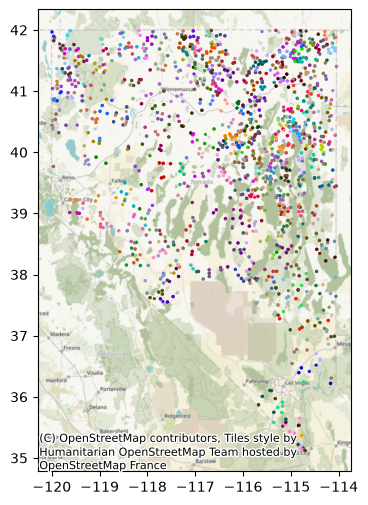

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

matched[matched.State=='NV'].sample(frac=1).plot(column='SegmentPolygonID', legend=False, markersize=2, alpha=.8, figsize=(8, 6), ax=ax,cmap=cmap)
ctx.add_basemap(ax, crs=matched.crs.to_string())

Test split by PSU

In [40]:
from sklearn.model_selection import train_test_split
# matched['StateCounty'] = matched['State'] + '-' + matched['CountyName']

train_psu, test_psu = train_test_split(matched['SegmentPolygonID'].unique().tolist(),test_size=0.5, random_state=20261007)
matched['test_split'] = matched['SegmentPolygonID'].isin(test_psu)
matched['test_split'].value_counts(), len(test_psu), len(test_psu)

(test_split
 True     4582
 False    4579
 Name: count, dtype: int64,
 2365,
 2365)

In [42]:
# save gdf to disk
matched.to_file('../../datasets/BLM_AIM/BLM_AIM_plots.gpkg')